Dimensionality reduction is a set of techniques that reduce the number of features (variables) in a dataset while retaining as much of the important information as possible. This is crucial for several reasons in machine learning and data analysis:

  * **Faster Computation:** Fewer features mean less data to process, leading to faster training and prediction times for machine learning models.
  * **Reduced Storage Space:** Storing less data is more efficient.
  * **Better Visualization:** It's easier to visualize data in 2D or 3D than in higher dimensions, helping to identify patterns and relationships.
  * **Mitigate the Curse of Dimensionality:** In high-dimensional spaces, data becomes sparse, making it harder for algorithms to find meaningful patterns and increasing the risk of overfitting.
  * **Noise Reduction:** Irrelevant or noisy features can be removed or combined, improving model performance.

Two prominent techniques for dimensionality reduction are **Principal Component Analysis (PCA)** and **Linear Discriminant Analysis (LDA)**.

-----

## Principal Component Analysis (PCA)

**Principal Component Analysis (PCA)** is an **unsupervised** dimensionality reduction technique. Its goal is to find a lower-dimensional representation of the data that captures the **maximum variance**. It transforms the original correlated features into a new set of uncorrelated features called **Principal Components (PCs)**. The first principal component captures the most variance, the second captures the most remaining variance orthogonal to the first, and so on.

### Formula and Concepts

1.  **Standardize the Data:** PCA is sensitive to the scale of features. It's crucial to standardize the data (mean = 0, standard deviation = 1) before applying PCA.
    $$z = \frac{x - \mu}{\sigma}$$
    where $x$ is the original feature value, $\\mu$ is the mean of the feature, and $\\sigma$ is the standard deviation of the feature.

2.  **Compute the Covariance Matrix:** The covariance matrix measures how features vary with respect to each other. For a dataset with $n$ features, the covariance matrix will be an $n \\times n$ symmetric matrix.
    $Cov(X, Y) = \frac{\sum_{i=1}^{N}(x_i - \bar{x})(y_i - \bar{y})}{N-1}$$
    The diagonal elements are the variances of individual features, and off-diagonal elements are the covariances between pairs of features.

3.  **Calculate Eigenvalues and Eigenvectors:**

      * **Eigenvectors** represent the directions (principal components) along which the data varies the most.
      * **Eigenvalues** represent the magnitude of variance along those directions. A larger eigenvalue indicates a more significant principal component.

    The eigenvectors and eigenvalues are found by solving the equation:
    $$C\mathbf{v} = \lambda\mathbf{v}$$
    where $C$ is the covariance matrix, $\\mathbf{v}$ is an eigenvector, and $\\lambda$ is its corresponding eigenvalue.

4.  **Sort Eigenvalues and Select Principal Components:** Sort the eigenvectors in descending order of their corresponding eigenvalues. The eigenvectors with the largest eigenvalues are the principal components that capture the most variance. You choose the top $k$ eigenvectors to form your new feature subspace, where $k$ is the desired number of dimensions.

5.  **Project the Data:** Project the original standardized data onto the selected principal components to obtain the new, reduced-dimension dataset.
    $$\text{Transformed Data} = \text{Original Data} \cdot \text{Selected Eigenvectors}$$

### Example Data and Code (PCA)

Let's use a simple 2D dataset and reduce it to 1D.

**Example Data:**

| Feature 1 | Feature 2 |
| :-------- | :-------- |
| 2         | 3         |
| 3         | 4         |
| 4         | 5         |
| 5         | 6         |

```python
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Create the example dataset
data = {
    'Feature 1': [2, 3, 4, 5],
    'Feature 2': [3, 4, 5, 6]
}
df = pd.DataFrame(data)
print("Original Data:\n", df)

# 2. Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
print("\nStandardized Data:\n", scaled_df)

# 3. Apply PCA
# We want to reduce to 1 dimension
pca = PCA(n_components=1)
pca_transformed_data = pca.fit_transform(scaled_data)

print(f"\nShape of original data: {scaled_data.shape}")
print(f"Shape of PCA transformed data (1D): {pca_transformed_data.shape}")

# The transformed data is an array, let's put it in a DataFrame for clarity
pca_df = pd.DataFrame(data=pca_transformed_data, columns=['Principal Component 1'])
print("\nPCA Transformed Data (1 Principal Component):\n", pca_df)

print("\nExplained Variance Ratio for each component:")
print(pca.explained_variance_ratio_) # How much variance each PC captures

print("\nPrincipal Components (Eigenvectors):")
print(pca.components_) # The new directions (vectors)

# Optional: Visualize the original and projected data (conceptual for 2D to 1D)
plt.figure(figsize=(8, 6))
plt.scatter(scaled_df['Feature 1'], scaled_df['Feature 2'], alpha=0.7, label='Original Standardized Data')

# Plot the first principal component direction (scaled for visualization)
# The first component is pca.components_[0]
# It represents the direction in the original feature space
# We can draw a line along this direction
mean_x = np.mean(scaled_df['Feature 1'])
mean_y = np.mean(scaled_df['Feature 2'])
# The component vector is normalized, scale it for better visualization
v0 = pca.components_[0][0] * 3 # Scale factor for visualization
v1 = pca.components_[0][1] * 3 # Scale factor for visualization
plt.plot([mean_x - v0, mean_x + v0], [mean_y - v1, mean_y + v1], color='red', linewidth=2, label='Principal Component 1')

# Project points onto the PC for visualization (inverse transform)
# This will show where the points would lie on the PC line
projected_points = pca.inverse_transform(pca_transformed_data)
plt.scatter(projected_points[:, 0], projected_points[:, 1], color='green', marker='x', s=100, label='Projected Data on PC1')


plt.title('PCA: Original Data and First Principal Component')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.axis('equal')
plt.show()
```

### Explanation of PCA Example

The example shows that PCA transforms the two original features (Feature 1, Feature 2) into a single new feature: **Principal Component 1**.

  * The `StandardScaler` makes sure that both features contribute equally to the variance calculation.
  * `pca.explained_variance_ratio_` will show a value close to `1.0` (or `[1.]` in this case) because almost all the variance in this highly correlated dataset can be captured by a single principal component.
  * `pca.components_` gives you the direction of the principal component in the original feature space. For `n_components=1`, it's an array like `[[0.707..., 0.707...]]`, meaning the principal component lies roughly along the line $y=x$ (a diagonal line in the feature space), which makes sense as our example data points are perfectly correlated.
  * The plot visually demonstrates how the original points are projected onto this new principal component axis, effectively reducing their dimensionality.

-----

## Linear Discriminant Analysis (LDA)

**Linear Discriminant Analysis (LDA)** is a **supervised** dimensionality reduction technique used for classification problems. Unlike PCA, which focuses on maximizing variance, LDA aims to find a lower-dimensional space that **maximizes the separation between classes** while minimizing the variance within each class. It's often used as a preprocessing step before classification.

### Formula and Concepts

LDA works by maximizing the ratio of **between-class scatter** to **within-class scatter**.

1.  **Calculate Mean Vectors:** Compute the mean vector for each class.
    $$\mu_k = \frac{1}{N_k} \sum_{x \in C_k} x$$
    where $\\mu\_k$ is the mean vector for class $k$, $N\_k$ is the number of samples in class $k$, and $C\_k$ is the set of samples belonging to class $k$.

2.  **Compute Within-Class Scatter Matrix ($S\_W$):** This matrix measures the scatter (variance) of samples within each class around their respective class means.
    $$S_W = \sum_{k=1}^{K} \sum_{x \in C_k} (x - \mu_k)(x - \mu_k)^T$$
    where $K$ is the total number of classes.

3.  **Compute Between-Class Scatter Matrix ($S\_B$):** This matrix measures the scatter of the class means around the overall mean of the data.
    $$\mu = \frac{1}{N} \sum_{i=1}^{N} x_i$$   $$S_B = \sum_{k=1}^{K} N_k (\mu_k - \mu)(\mu_k - \mu)^T$$
    where $\\mu$ is the overall mean of all data points.

4.  **Solve the Generalized Eigenvalue Problem:** LDA seeks to find a projection vector $\\mathbf{w}$ that maximizes Fisher's criterion:
    $$J(\mathbf{w}) = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$$
    This is equivalent to solving the generalized eigenvalue problem:
    $$S_B \mathbf{w} = \lambda S_W \mathbf{w}$$
    Which can be rewritten as:
    $$S_W^{-1} S_B \mathbf{w} = \lambda \mathbf{w}$$
    The eigenvectors of $S\_W^{-1} S\_B$ are the linear discriminants, and the corresponding eigenvalues indicate their importance.

5.  **Sort Eigenvalues and Select Linear Discriminants:** Sort the eigenvectors in descending order of their corresponding eigenvalues. The eigenvectors with the largest eigenvalues are the most discriminative. The maximum number of linear discriminants (new dimensions) you can get is $K-1$ (where $K$ is the number of classes) or the number of features, whichever is smaller.

6.  **Project the Data:** Project the original data onto the selected linear discriminants.
    $$\text{Transformed Data} = \text{Original Data} \cdot \text{Selected Eigenvectors}$$

### Example Data and Code (LDA)

Let's use a simple dataset with two classes.

**Example Data:**

| Feature 1 | Feature 2 | Class     |
| :-------- | :-------- | :-------- |
| 1         | 2         | Red       |
| 2         | 3         | Red       |
| 3         | 2         | Red       |
| 5         | 6         | Blue      |
| 6         | 7         | Blue      |
| 7         | 6         | Blue      |

```python
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create the example dataset
data = {
    'Feature 1': [1, 2, 3, 5, 6, 7],
    'Feature 2': [2, 3, 2, 6, 7, 6],
    'Class': ['Red', 'Red', 'Red', 'Blue', 'Blue', 'Blue']
}
df = pd.DataFrame(data)
print("Original Data:\n", df)

X = df[['Feature 1', 'Feature 2']]
y = df['Class']

# 2. Standardize the data (recommended for LDA as well)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("\nStandardized Features:\n", X_scaled_df)

# 3. Apply LDA
# For 2 classes, LDA will produce at most 1 discriminant component (K-1)
lda = LinearDiscriminantAnalysis(n_components=1)
lda_transformed_data = lda.fit_transform(X_scaled, y)

print(f"\nShape of original features: {X_scaled.shape}")
print(f"Shape of LDA transformed data (1D): {lda_transformed_data.shape}")

lda_df = pd.DataFrame(data=lda_transformed_data, columns=['Linear Discriminant 1'])
lda_df['Class'] = y
print("\nLDA Transformed Data (1 Linear Discriminant):\n", lda_df)

# Optional: Visualize the original and projected data
plt.figure(figsize=(12, 5))

# Original 2D data
plt.subplot(1, 2, 1)
sns.scatterplot(x='Feature 1', y='Feature 2', hue='Class', data=pd.concat([X_scaled_df, y], axis=1), s=100, alpha=0.8)
plt.title('Original Data (Standardized) by Class')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.grid(True, linestyle='--', alpha=0.6)

# LDA transformed 1D data
plt.subplot(1, 2, 2)
# Create a jitter for better visualization of 1D points
jittered_y = np.random.rand(len(lda_df)) * 0.1 - 0.05 # small random vertical spread
sns.scatterplot(x='Linear Discriminant 1', y=jittered_y, hue='Class', data=lda_df, s=100, alpha=0.8)
plt.title('LDA Transformed Data (1D)')
plt.xlabel('Linear Discriminant 1')
plt.yticks([]) # Hide y-axis ticks as it's a 1D projection
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()
```

### Explanation of LDA Example

In the LDA example:

  * The original data has two features and two classes ('Red' and 'Blue').
  * `StandardScaler` is applied first for consistent scaling.
  * `LinearDiscriminantAnalysis(n_components=1)` transforms the 2D data into a 1D representation. Since there are 2 classes, LDA can create at most $2-1=1$ discriminant.
  * The output `lda_transformed_data` is a 1D array where points from different classes are maximally separated.
  * The plots clearly show the difference:
      * The **left plot** shows the original data points in 2D, colored by their class. The classes are linearly separable.
      * The **right plot** shows the data points projected onto a single dimension (the "Linear Discriminant 1"). Notice how the 'Red' points are grouped together on one side of the axis, and the 'Blue' points are on the other, indicating successful class separation along this new dimension. LDA finds the optimal direction that best distinguishes between these classes.

-----

### PCA vs. LDA: Key Differences 🎯

| Feature             | PCA                                       | LDA                                         |
| :------------------ | :---------------------------------------- | :------------------------------------------ |
| **Type** | Unsupervised                              | Supervised                                  |
| **Goal** | Maximize **variance** in projected data   | Maximize **class separability** |
| **Information Used**| Feature values only                       | Feature values **and class labels** |
| **Applications** | Data compression, noise reduction, visualization, general feature extraction | Classification, face recognition (e.g., Fisherfaces) |
| **Output Components** | Up to $\\text{min}(\\text{samples}, \\text{features})$ | Up to $\\text{min}(\\text{classes} - 1, \\text{features})$ |
| **Assumptions** | None explicitly on data distribution (though often used with linearly separable data) | Assumes normally distributed data and equal covariance matrices among classes |

In summary, if your primary goal is to reduce dimensions while preserving the most overall information/variance, use **PCA**. If your goal is to reduce dimensions to improve classification performance by enhancing class separability, and you have labeled data, then **LDA** is typically a better choice.

Original Data:
    Feature 1  Feature 2
0          2          3
1          3          4
2          4          5
3          5          6

Standardized Data:
    Feature 1  Feature 2
0  -1.341641  -1.341641
1  -0.447214  -0.447214
2   0.447214   0.447214
3   1.341641   1.341641

Shape of original data: (4, 2)
Shape of PCA transformed data (1D): (4, 1)

PCA Transformed Data (1 Principal Component):
    Principal Component 1
0              -1.897367
1              -0.632456
2               0.632456
3               1.897367

Explained Variance Ratio for each component:
[1.]

Principal Components (Eigenvectors):
[[0.70710678 0.70710678]]


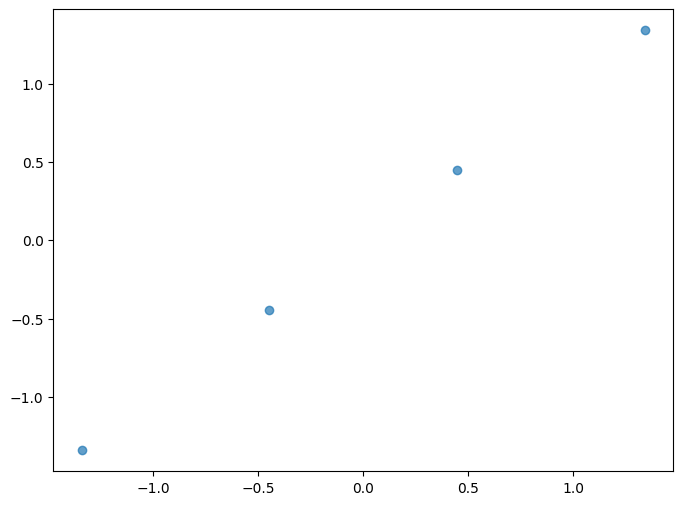

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Create the example dataset
data = {
    'Feature 1': [2, 3, 4, 5],
    'Feature 2': [3, 4, 5, 6]
}
df = pd.DataFrame(data)
print("Original Data:\n", df)

# 2. Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
print("\nStandardized Data:\n", scaled_df)

# 3. Apply PCA
# We want to reduce to 1 dimension
pca = PCA(n_components=1)
pca_transformed_data = pca.fit_transform(scaled_data)

print(f"\nShape of original data: {scaled_data.shape}")
print(f"Shape of PCA transformed data (1D): {pca_transformed_data.shape}")

# The transformed data is an array, let's put it in a DataFrame for clarity
pca_df = pd.DataFrame(data=pca_transformed_data, columns=['Principal Component 1'])
print("\nPCA Transformed Data (1 Principal Component):\n", pca_df)

print("\nExplained Variance Ratio for each component:")
print(pca.explained_variance_ratio_) # How much variance each PC captures

print("\nPrincipal Components (Eigenvectors):")
print(pca.components_) # The new directions (vectors)

# Optional: Visualize the original and projected data (conceptual for 2D to 1D)
plt.figure(figsize=(8, 6))
plt.scatter(scaled_df['Feature 1'], scaled_df['Feature 2'], alpha=0.7, label='Original Standardized Data')

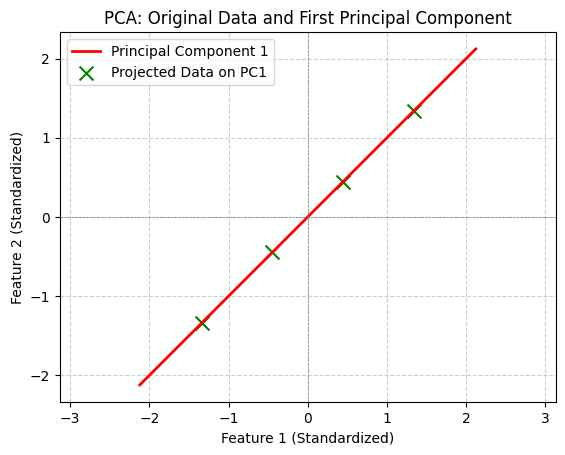

In [3]:

# Plot the first principal component direction (scaled for visualization)
# The first component is pca.components_[0]
# It represents the direction in the original feature space
# We can draw a line along this direction
mean_x = np.mean(scaled_df['Feature 1'])
mean_y = np.mean(scaled_df['Feature 2'])
# The component vector is normalized, scale it for better visualization
v0 = pca.components_[0][0] * 3 # Scale factor for visualization
v1 = pca.components_[0][1] * 3 # Scale factor for visualization
plt.plot([mean_x - v0, mean_x + v0], [mean_y - v1, mean_y + v1], color='red', linewidth=2, label='Principal Component 1')

# Project points onto the PC for visualization (inverse transform)
# This will show where the points would lie on the PC line
projected_points = pca.inverse_transform(pca_transformed_data)
plt.scatter(projected_points[:, 0], projected_points[:, 1], color='green', marker='x', s=100, label='Projected Data on PC1')


plt.title('PCA: Original Data and First Principal Component')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.axis('equal')
plt.show()

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create the example dataset
data = {
    'Feature 1': [1, 2, 3, 5, 6, 7],
    'Feature 2': [2, 3, 2, 6, 7, 6],
    'Class': ['Red', 'Red', 'Red', 'Blue', 'Blue', 'Blue']
}
df = pd.DataFrame(data)
print("Original Data:\n", df)

X = df[['Feature 1', 'Feature 2']]
y = df['Class']


Original Data:
    Feature 1  Feature 2 Class
0          1          2   Red
1          2          3   Red
2          3          2   Red
3          5          6  Blue
4          6          7  Blue
5          7          6  Blue


In [5]:

# 2. Standardize the data (recommended for LDA as well)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("\nStandardized Features:\n", X_scaled_df)




Standardized Features:
    Feature 1  Feature 2
0   -1.38873  -1.135550
1   -0.92582  -0.648886
2   -0.46291  -1.135550
3    0.46291   0.811107
4    0.92582   1.297771
5    1.38873   0.811107


In [6]:
# 3. Apply LDA
# For 2 classes, LDA will produce at most 1 discriminant component (K-1)
lda = LinearDiscriminantAnalysis(n_components=1)
lda_transformed_data = lda.fit_transform(X_scaled, y)

print(f"\nShape of original features: {X_scaled.shape}")
print(f"Shape of LDA transformed data (1D): {lda_transformed_data.shape}")

lda_df = pd.DataFrame(data=lda_transformed_data, columns=['Linear Discriminant 1'])
lda_df['Class'] = y
print("\nLDA Transformed Data (1 Linear Discriminant):\n", lda_df)



Shape of original features: (6, 2)
Shape of LDA transformed data (1D): (6, 1)

LDA Transformed Data (1 Linear Discriminant):
    Linear Discriminant 1 Class
0                    5.0   Red
1                    3.0   Red
2                    4.0   Red
3                   -3.0  Blue
4                   -5.0  Blue
5                   -4.0  Blue


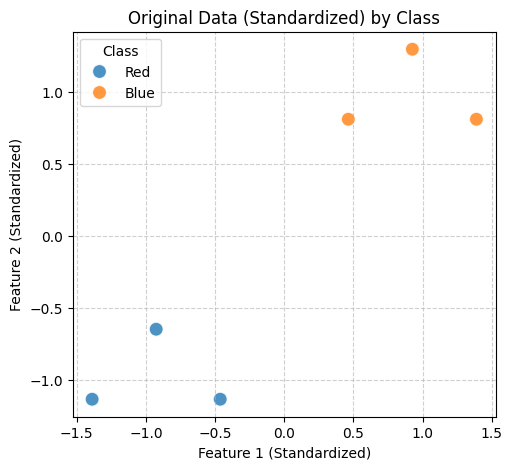

In [7]:

# Optional: Visualize the original and projected data
plt.figure(figsize=(12, 5))

# Original 2D data
plt.subplot(1, 2, 1)
sns.scatterplot(x='Feature 1', y='Feature 2', hue='Class', data=pd.concat([X_scaled_df, y], axis=1), s=100, alpha=0.8)
plt.title('Original Data (Standardized) by Class')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.grid(True, linestyle='--', alpha=0.6)



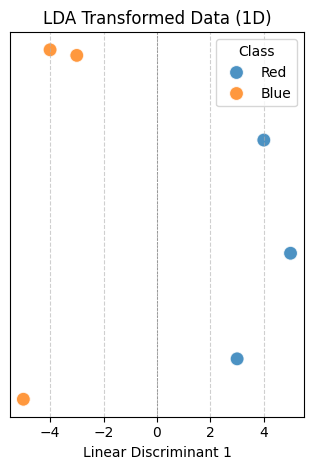

In [8]:
# LDA transformed 1D data
plt.subplot(1, 2, 2)
# Create a jitter for better visualization of 1D points
jittered_y = np.random.rand(len(lda_df)) * 0.1 - 0.05 # small random vertical spread
sns.scatterplot(x='Linear Discriminant 1', y=jittered_y, hue='Class', data=lda_df, s=100, alpha=0.8)
plt.title('LDA Transformed Data (1D)')
plt.xlabel('Linear Discriminant 1')
plt.yticks([]) # Hide y-axis ticks as it's a 1D projection
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

https://www.geeksforgeeks.org/machine-learning/dimensionality-reduction/
https://www.geeksforgeeks.org/machine-learning/dimensionality-reduction/
https://www.datacamp.com/tutorial/understanding-dimensionality-reduction
https://www.analyticsvidhya.com/blog/2018/08/dimensionality-reduction-techniques-python/

In [9]:
http://machinelearningmastery.com/dimensionality-reduction-algorithms-with-python/

SyntaxError: invalid syntax (ipython-input-9-2661024654.py, line 1)